In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

crop_df = pd.read_csv("crop_yield.csv")
rainfall_df = pd.read_csv("rainfall_vs_crop_production_tableau.csv")
rainfall_df

,Year,State,Crop,Area (hectares),Production (tonnes),Yield (tonnes/hectare),Annual Rainfall (mm)
0,1997,Assam,Arecanut,73814.0,56708,0.796087,2051.4
1,1997,Assam,Arhar/Tur,6637.0,4685,0.710435,2051.4
2,1997,Assam,Castor seed,796.0,22,0.238333,2051.4
3,1997,Assam,Coconut,19656.0,126905000,5238.051739,2051.4
4,1997,Assam,Cotton(lint),1739.0,794,0.420909,2051.4
...,...,...,...,...,...,...,...
19684,1998,Nagaland,Small millets,4000.0,2000,0.500000,1498.0
19685,1998,Nagaland,Wheat,1000.0,3000,3.000000,1498.0
19686,1997,Jammu and Kashmir,Maize,310883.0,440900,1.285000,1356.2
19687,1997,Jammu and Kashmir,Rice,275746.0,5488,0.016667,1356.2


In [2]:
rainfall_df.describe()

,Year,Area (hectares),Production (tonnes),Yield (tonnes/hectare),Annual Rainfall (mm)
count,19689.000000,1.968900e+04,1.968900e+04,19689.000000,19689.000000
mean,2009.127584,1.799266e+05,1.643594e+07,79.954009,1437.755177
std,6.498099,7.328287e+05,2.630568e+08,878.306193,816.909589
min,1997.000000,5.000000e-01,0.000000e+00,0.000000,301.300000
25%,2004.000000,1.390000e+03,1.393000e+03,0.600000,940.700000
50%,2010.000000,9.317000e+03,1.380400e+04,1.030000,1247.600000
75%,2015.000000,7.511200e+04,1.227180e+05,2.388889,1643.700000
max,2020.000000,5.080810e+07,6.326000e+09,21105.000000,6552.700000


In [3]:
rainfall_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 19689 entries, 0 to 19688
Data columns (total 7 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Year                    19689 non-null  int64  
 1   State                   19689 non-null  str    
 2   Crop                    19689 non-null  str    
 3   Area (hectares)         19689 non-null  float64
 4   Production (tonnes)     19689 non-null  int64  
 5   Yield (tonnes/hectare)  19689 non-null  float64
 6   Annual Rainfall (mm)    19689 non-null  float64
dtypes: float64(3), int64(2), str(2)
memory usage: 1.1 MB


In [4]:
# Standardize column names
crop_df.columns = crop_df.columns.str.strip().str.lower()
rainfall_df.columns = rainfall_df.columns.str.strip().str.lower()

# Rename columns
crop_df.rename(columns={
    "crop_year": "year",
    "state": "state",
    "production": "production"
}, inplace=True)

rainfall_df.rename(columns={
    "annual rainfall (mm)": "rainfall",
    "year": "year",
    "state": "state"
}, inplace=True)

# Fill missing values
crop_df.fillna(0, inplace=True)
rainfall_df.fillna(0, inplace=True)

# Drop unnecessary columns
crop_df.drop(columns=["fertilizer", "pesticide"], errors="ignore", inplace=True)

In [5]:
rainfall_df.head()

,year,state,crop,area (hectares),production (tonnes),yield (tonnes/hectare),rainfall
0,1997,Assam,Arecanut,73814.0,56708,0.796087,2051.4
1,1997,Assam,Arhar/Tur,6637.0,4685,0.710435,2051.4
2,1997,Assam,Castor seed,796.0,22,0.238333,2051.4
3,1997,Assam,Coconut,19656.0,126905000,5238.051739,2051.4
4,1997,Assam,Cotton(lint),1739.0,794,0.420909,2051.4


In [6]:
crop_df = crop_df[(crop_df["year"] >= 2000) & (crop_df["year"] <= 2015)]
rainfall_df = rainfall_df[(rainfall_df["year"] >= 2000) & (rainfall_df["year"] <= 2015)]

print("Crop Dataset Shape:", crop_df.shape)
print("Rainfall Dataset Shape:", rainfall_df.shape)

crop_df.head(), rainfall_df.head()

Crop Dataset Shape: (13698, 8)
Rainfall Dataset Shape: (13698, 7)


(          crop  year       season           state      area  production  \
 490   Arecanut  2000  Whole Year   Andhra Pradesh     262.0         724   
 491  Arhar/Tur  2000  Kharif       Andhra Pradesh  507366.0      216457   
 492  Arhar/Tur  2000  Rabi         Andhra Pradesh    6098.0        2701   
 493      Bajra  2000  Kharif       Andhra Pradesh  129475.0      135964   
 494      Bajra  2000  Rabi         Andhra Pradesh   14229.0       12524   
 
      annual_rainfall     yield  
 490            935.6  2.780000  
 491            935.6  0.433182  
 492            935.6  0.423750  
 493            935.6  1.001667  
 494            935.6  0.883125  ,
      year           state       crop  area (hectares)  production (tonnes)  \
 490  2000  Andhra Pradesh   Arecanut            262.0                  724   
 491  2000  Andhra Pradesh  Arhar/Tur         507366.0               216457   
 492  2000  Andhra Pradesh  Arhar/Tur           6098.0                 2701   
 493  2000  Andhra Pr

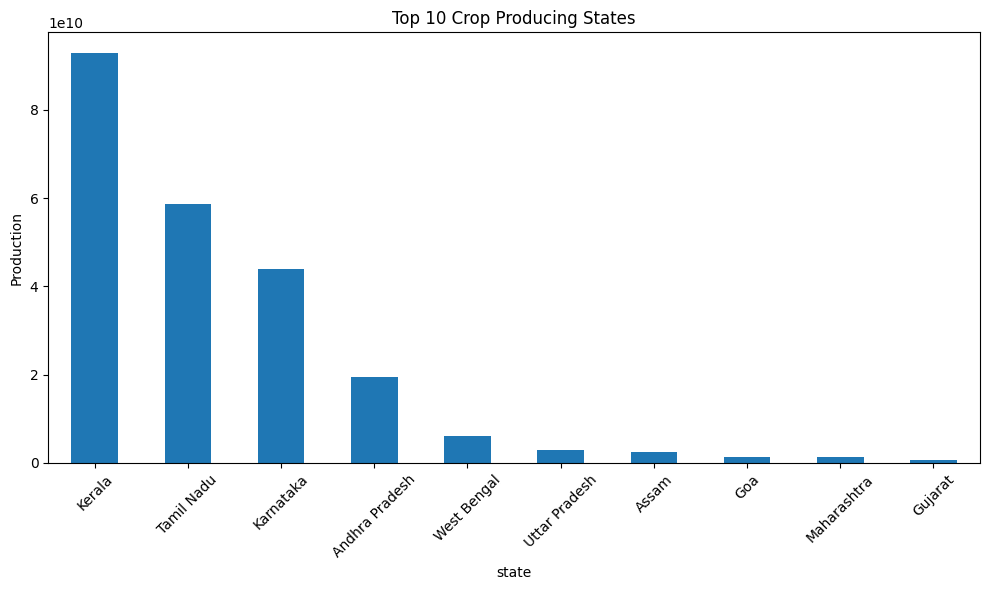

In [7]:
top_states = crop_df.groupby("state")["production"].sum().nlargest(10)

plt.figure(figsize=(10,6))
top_states.plot(kind="bar")
plt.title("Top 10 Crop Producing States")
plt.ylabel("Production")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
def create_line_plot(df, x, y, hue, title):
    plt.figure(figsize=(12, 6))
    sns.lineplot(data=df, x=x, y=y, hue=hue, legend=False)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def create_histogram(df, x, title):
    plt.figure(figsize=(10, 5))
    sns.histplot(df[x], bins=20)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def create_scatter_plot(df, x, y, title):
    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df, x=x, y=y)
    plt.title(title)
    plt.tight_layout()
    plt.show()

def create_heatmap(df, index, columns, values, title):
    pivot = df.pivot_table(index=index, columns=columns, values=values, aggfunc="mean")
    plt.figure(figsize=(12, 8))
    sns.heatmap(pivot, cmap="YlGnBu")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def create_box_plot(df, x, y, title):
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x=x, y=y)
    plt.xticks(rotation=45)
    plt.title(title)
    plt.tight_layout()
    plt.show()

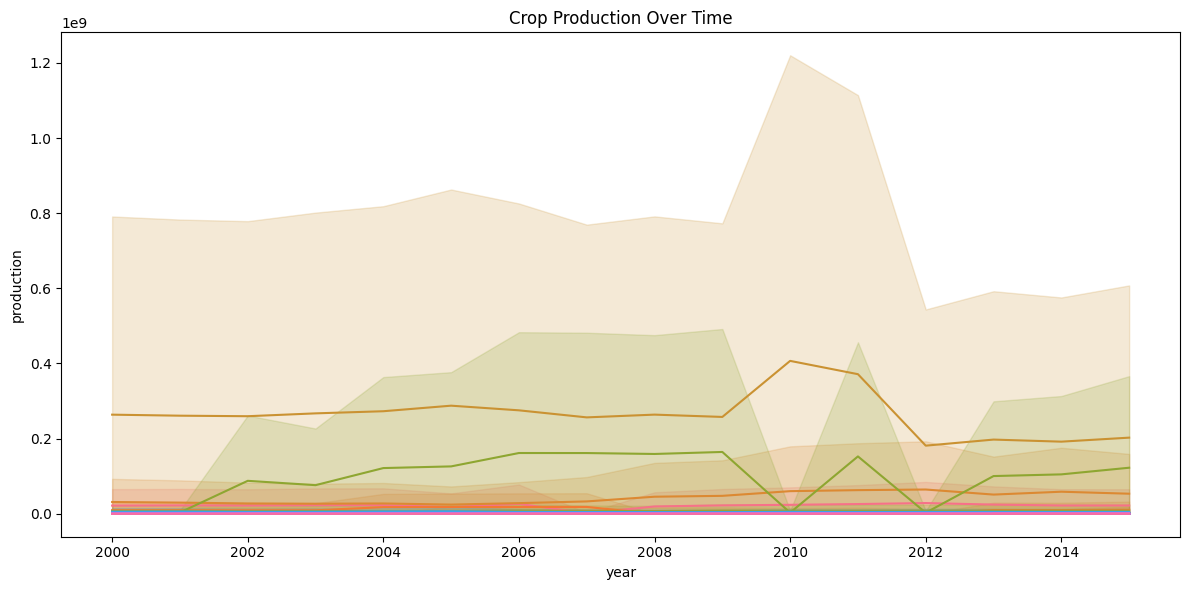

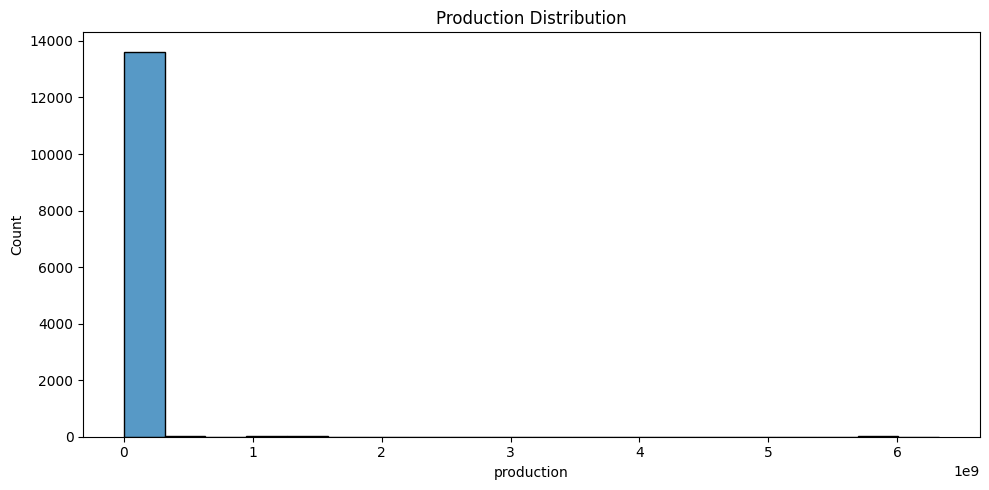

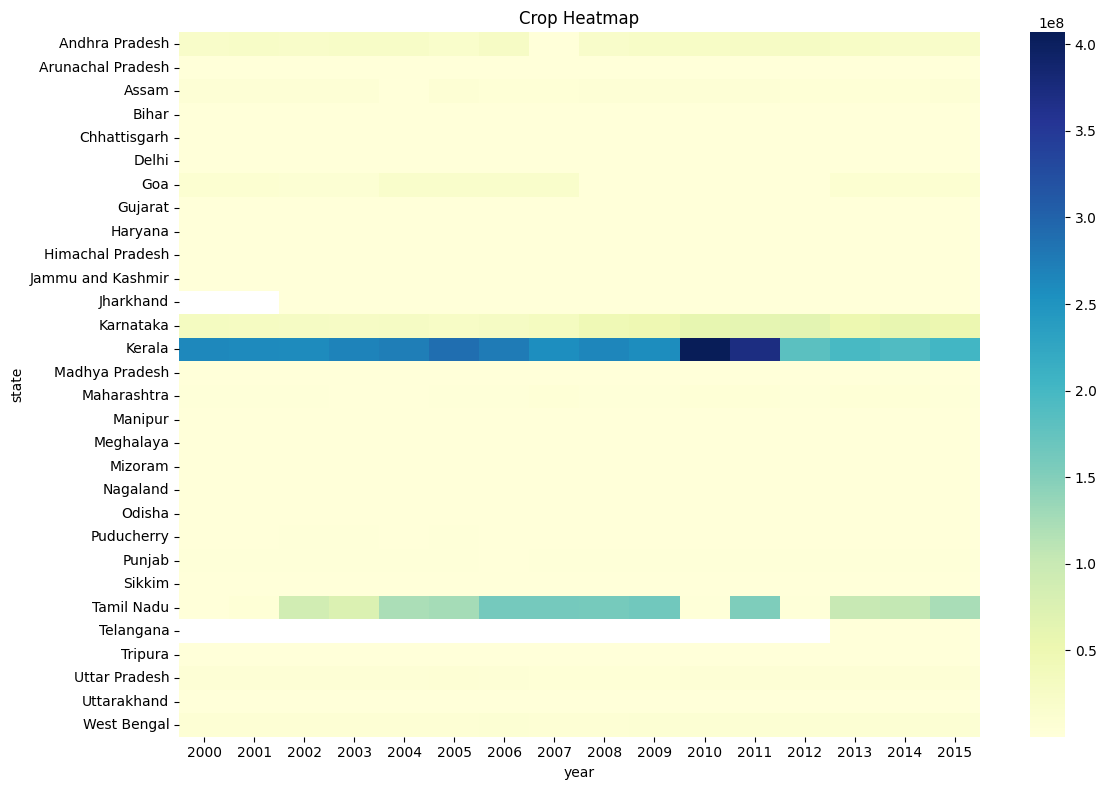

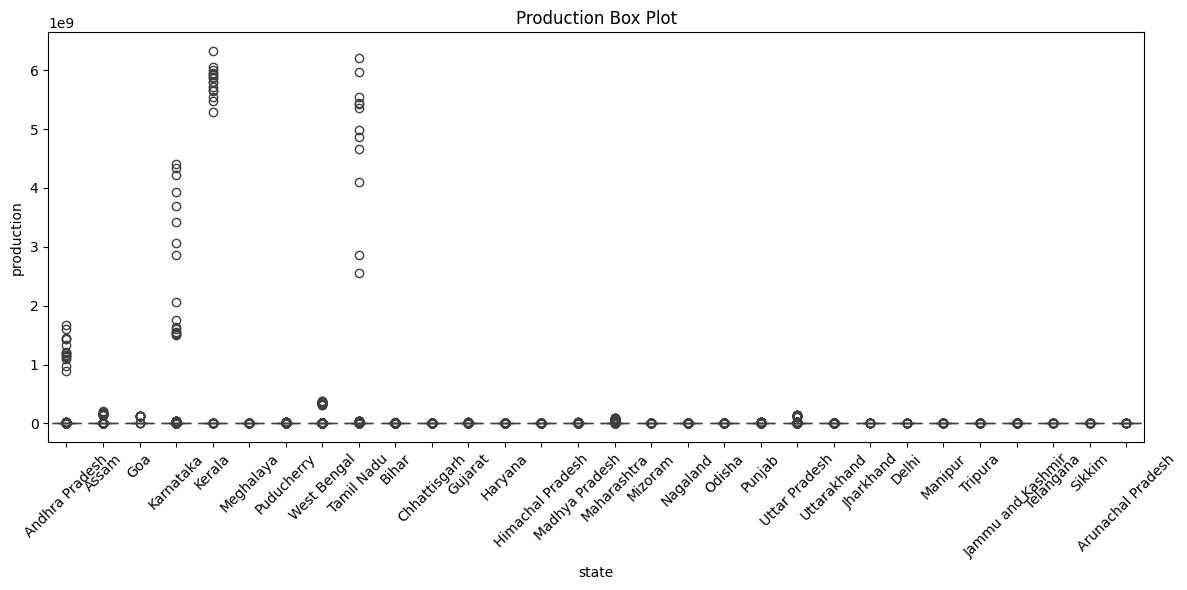

In [9]:
create_line_plot(crop_df, 'year', 'production', 'state', "Crop Production Over Time")
create_histogram(crop_df, 'production', "Production Distribution")
create_heatmap(crop_df, 'state', 'year', 'production', "Crop Heatmap")
create_box_plot(crop_df, 'state', 'production', "Production Box Plot")

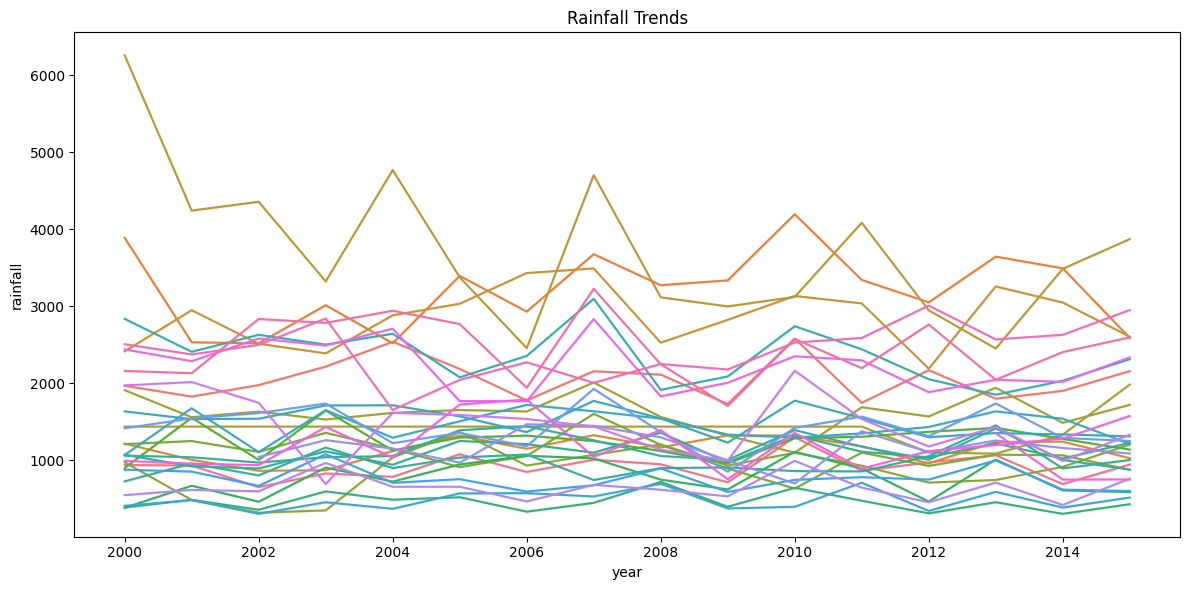

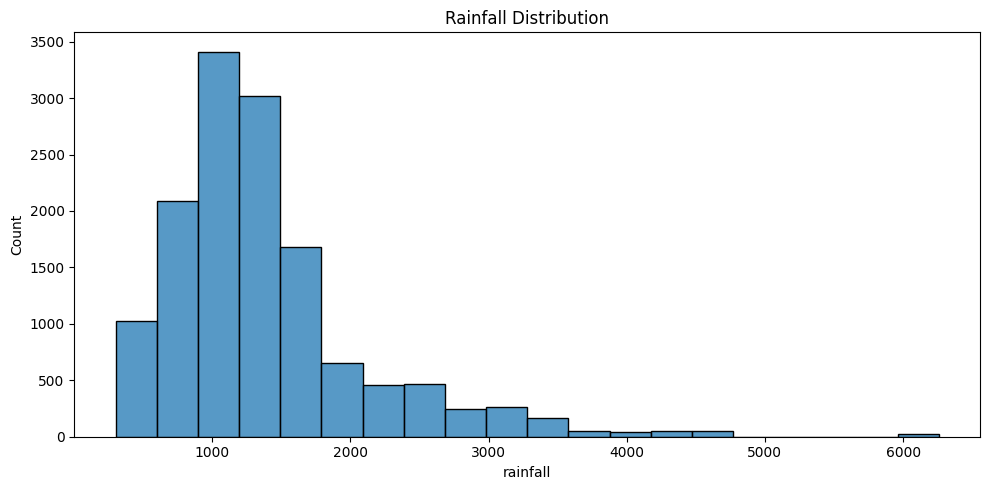

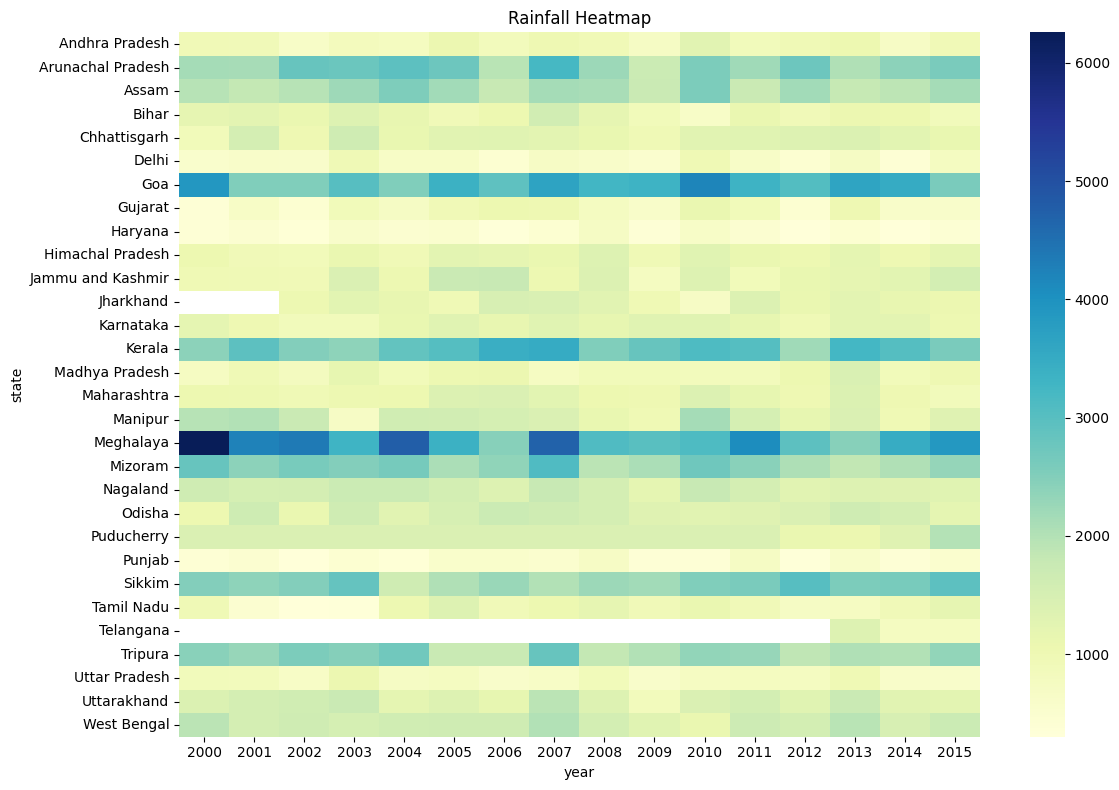

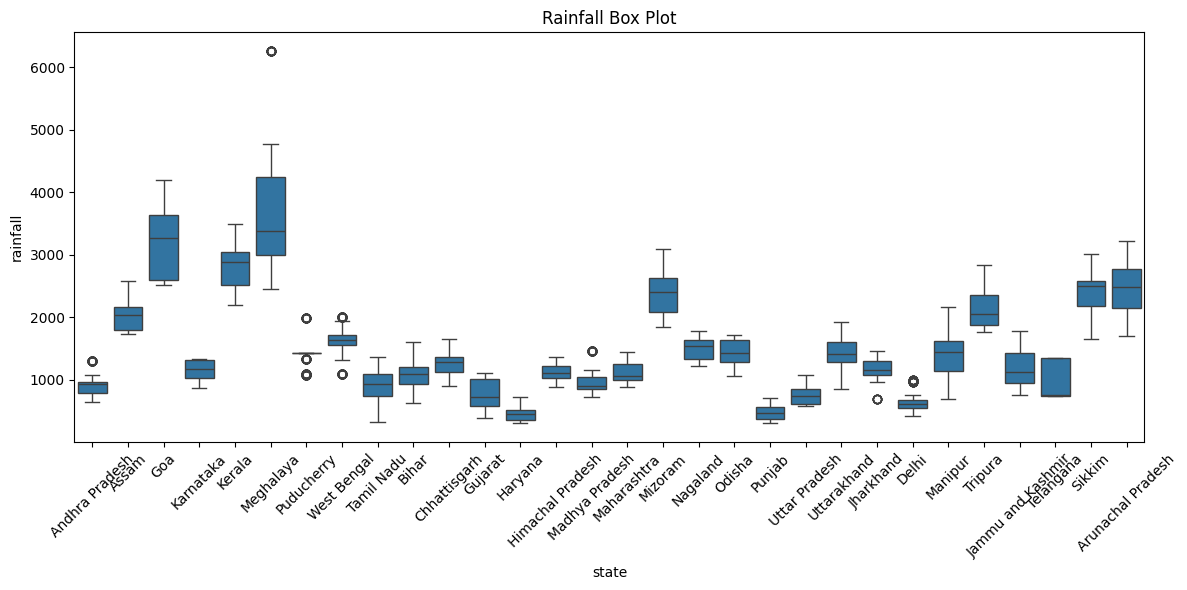

In [10]:
create_line_plot(rainfall_df, 'year', 'rainfall', 'state', "Rainfall Trends")
create_histogram(rainfall_df, 'rainfall', "Rainfall Distribution")
create_heatmap(rainfall_df, 'state', 'year', 'rainfall', "Rainfall Heatmap")
create_box_plot(rainfall_df, 'state', 'rainfall', "Rainfall Box Plot")

In [11]:
merged_df = pd.merge(
    crop_df,
    rainfall_df,
    on=["state", "year"],
    how="inner"
)

merged_df.head()

,crop_x,year,season,state,area,production,annual_rainfall,yield,crop_y,area (hectares),production (tonnes),yield (tonnes/hectare),rainfall
0,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,935.6,2.78,Arecanut,262.0,724,2.780000,935.6
1,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,935.6,2.78,Arhar/Tur,507366.0,216457,0.433182,935.6
2,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,935.6,2.78,Arhar/Tur,6098.0,2701,0.423750,935.6
3,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,935.6,2.78,Bajra,129475.0,135964,1.001667,935.6
4,Arecanut,2000,Whole Year,Andhra Pradesh,262.0,724,935.6,2.78,Bajra,14229.0,12524,0.883125,935.6


In [12]:
correlation = merged_df["production"].corr(merged_df["rainfall"])
print("Correlation (Rainfall vs Production):", correlation)

Correlation (Rainfall vs Production): 0.02281718745564534


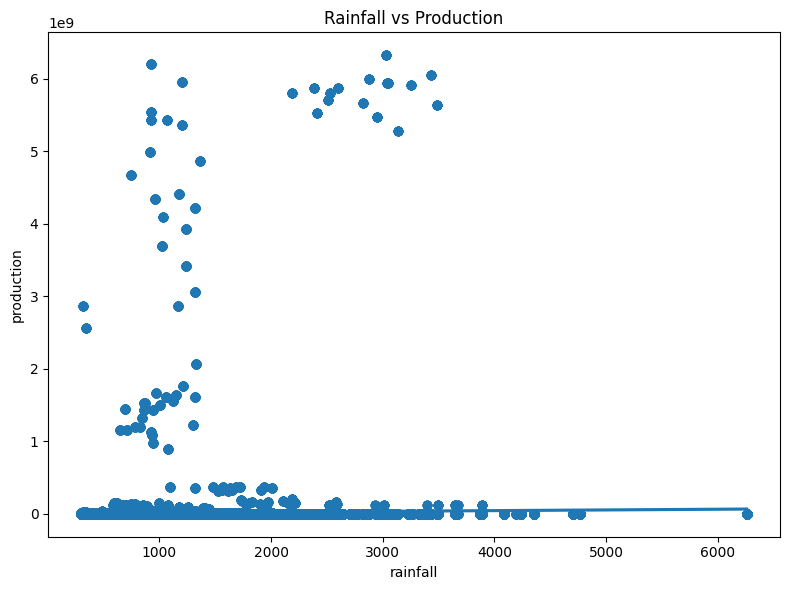

In [15]:
plt.figure(figsize=(8,6))
sns.regplot(data=merged_df, x="rainfall", y="production")
plt.title("Rainfall vs Production")
plt.tight_layout()
plt.show()

In [16]:
print("--- FINAL INSIGHTS ---")
print("1. Production is concentrated in a few states.")
print("2. Rainfall varies significantly across regions.")
print("3. Weak/moderate correlation between rainfall and production.")
print("4. Other factors like irrigation and soil affect yield.")

--- FINAL INSIGHTS ---
1. Production is concentrated in a few states.
2. Rainfall varies significantly across regions.
3. Weak/moderate correlation between rainfall and production.
4. Other factors like irrigation and soil affect yield.
